In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

VIDEO_PATH = "../data/raw/Registro A_2.MOV"
cap = cv2.VideoCapture(VIDEO_PATH)

print("Video abierto:", cap.isOpened())
print("Cantidad de frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("FPS:", cap.get(cv2.CAP_PROP_FPS))
print("Ancho:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("Alto:", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

cap.release()

ROI_PATH = "../data/reference/roi_A_gray.png"

roi_gray = cv2.imread(ROI_PATH, cv2.IMREAD_GRAYSCALE)

if roi_gray is None:
    raise RuntimeError(f"No se pudo cargar la ROI: {ROI_PATH}")

print("ROI cargada correctamente.")
print("Dimensiones:", roi_gray.shape)

Video abierto: True
Cantidad de frames: 956
FPS: 29.97804954531201
Ancho: 1920
Alto: 1080
ROI cargada correctamente.
Dimensiones: (130, 320)


Se carga el video y la ROI seleccionada en el módulo 1 para aplicarle los métodos de segmentación y observar su funcionamiento. 

Se aplica el método de Otsu para determinar automáticamente un umbral que permita separar la región oscura correspondiente a la pupila del resto de la imagen. Luego se realiza una operación morfológica para eliminar pequeños objetos y suavizar la región segmentada.

Umbral de Otsu: 107.0


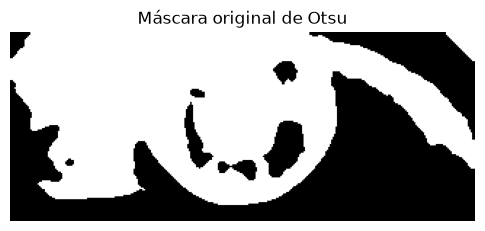

In [72]:
# Otsu sin operaciones morfológicas
blur = cv2.GaussianBlur(roi_gray, (5, 5), sigmaX=2)
threshold, mask_otsu_original = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print("Umbral de Otsu:", threshold)

plt.figure(figsize=(6, 5))
plt.imshow(mask_otsu_original, cmap="gray")
plt.title("Máscara original de Otsu")
plt.axis("off")
plt.show()


Se utiliza el algoritmo K-Means para agrupar los píxeles de la imagen en distintos grupos según sus características de color e intensidad. Se evalúan valores de K entre 2 y 5 para analizar cómo cambia la segmentación de la pupila al aumentar la cantidad de grupos.

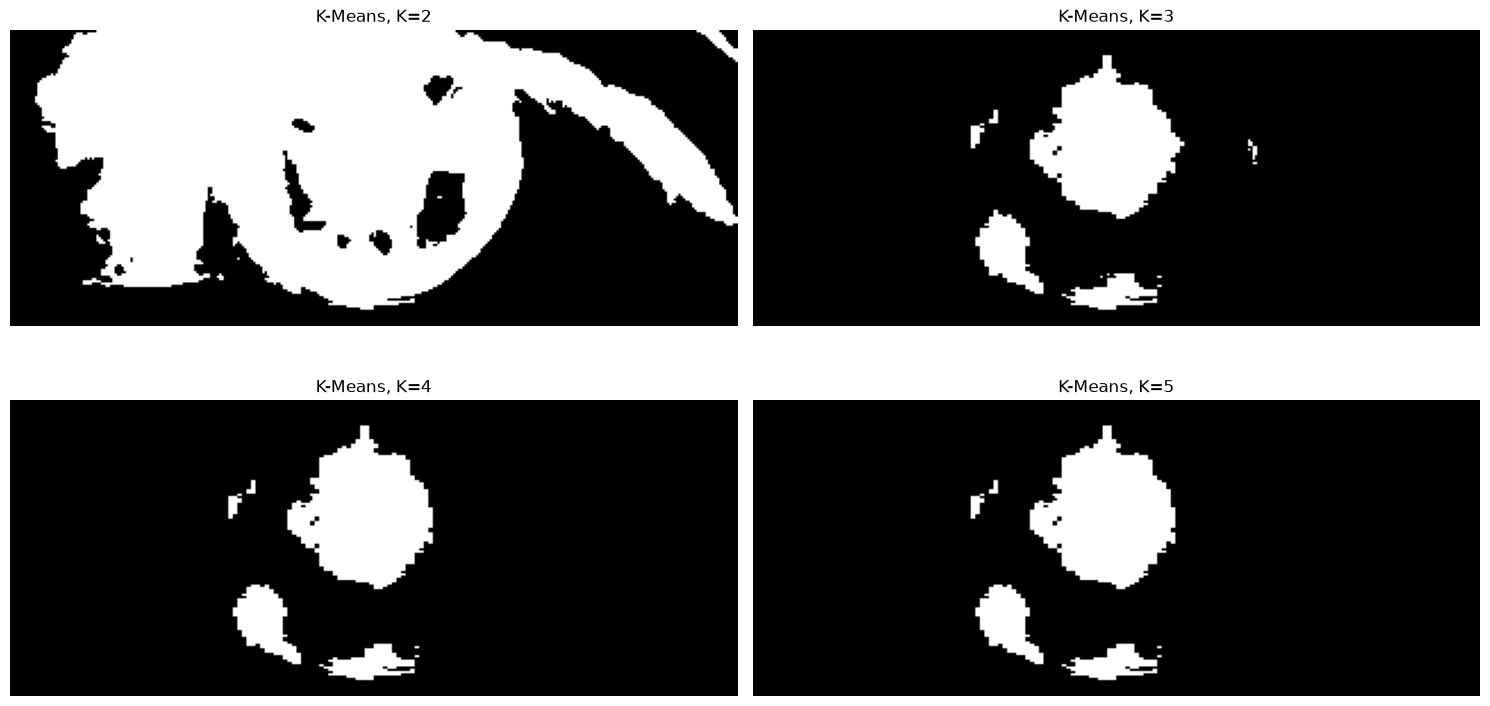

In [73]:
ROI_RGB_PATH = "../data/reference/roi_A_rgb.png"

roi_rgb = cv2.imread(ROI_RGB_PATH)

hsv = cv2.cvtColor(roi_rgb, cv2.COLOR_BGR2HSV)
pixels = hsv.reshape((-1, 3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
results_kmeans = {}

for k in range(2, 6):
    _, labels, centers = cv2.kmeans(pixels,k,None,criteria,10,cv2.KMEANS_PP_CENTERS)

    labels = labels.flatten()
    centers = centers.astype(np.uint8)

    cluster_image = centers[labels]
    cluster_image = cluster_image.reshape(hsv.shape)

    value_image = cluster_image[:, :, 2]

    darkest_cluster = np.argmin(centers[:, 2])

    mask = (labels == darkest_cluster).astype(np.uint8) * 255
    mask = mask.reshape(hsv.shape[:2])

    results_kmeans[k] = mask

plt.figure(figsize=(15, 8))

for i, k in enumerate(range(2, 6)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(results_kmeans[k], cmap="gray")
    plt.title(f"K-Means, K={k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Usamos un contorno activo para localizar los bordes de la pupila. Definimos manualmente una curva cerrada próxima al borde pupilar y dejamos que evolucione en función de las características de la imagen hasta converger hacia la frontera de la estructura.

In [74]:
from skimage.segmentation import active_contour
from skimage.filters import gaussian
from skimage.draw import polygon

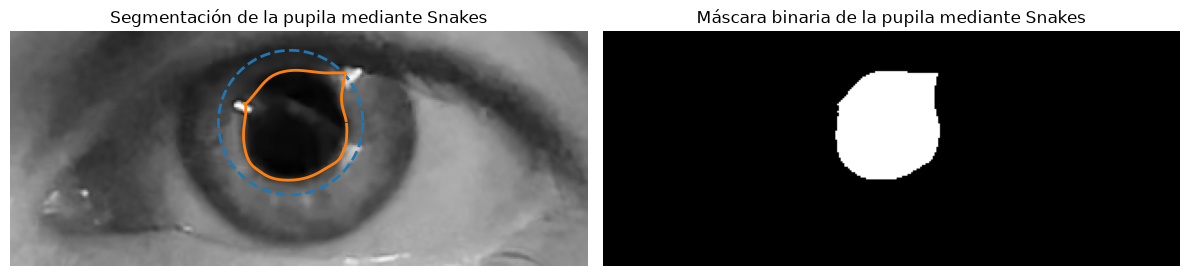

In [75]:
gray_eye = roi_gray.astype(np.float64) / 255.0
smooth_eye = gaussian(gray_eye, sigma=2)

center_x = 155
center_y = 50

# Un poco más grande que la pupila
radius_x = 40
radius_y = 40
theta = np.linspace(0, 2*np.pi, 150)

x = center_x + radius_x * np.cos(theta)
y = center_y + radius_y * np.sin(theta)

init = np.column_stack((y, x))

snake = active_contour(smooth_eye,init,alpha=0.05,beta=0.01,gamma=0.5,w_line=0.1,w_edge=1,max_num_iter=1500,convergence=0.001)

# Crear una máscara inicialmente negra
mask_snake = np.zeros(gray_eye.shape, dtype=np.uint8)

# Coordenadas del contorno: filas (y) y columnas (x)
rr, cc = polygon(
    snake[:, 0],
    snake[:, 1],
    shape=gray_eye.shape
)

# Rellenar el interior del contorno
mask_snake[rr, cc] = 1

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_eye, cmap="gray")
plt.plot(init[:, 1],init[:, 0],"--",linewidth=2,label="Contorno inicial")
plt.plot(snake[:, 1],snake[:, 0],linewidth=2,label="Snake final")
plt.title("Segmentación de la pupila mediante Snakes")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_snake, cmap="gray", vmin=0, vmax=1)
plt.title("Máscara binaria de la pupila mediante Snakes")
plt.axis("off")

plt.tight_layout()
plt.show()

Antes de aplicar Watershed, primero calculamos el gradiente de la imagen y definimos marcadores de regiones. 

Decidimos aumentar el contraste de la imagen porque no se observaba bien el cambio entre el iris y la pupila ya a simple vista. 

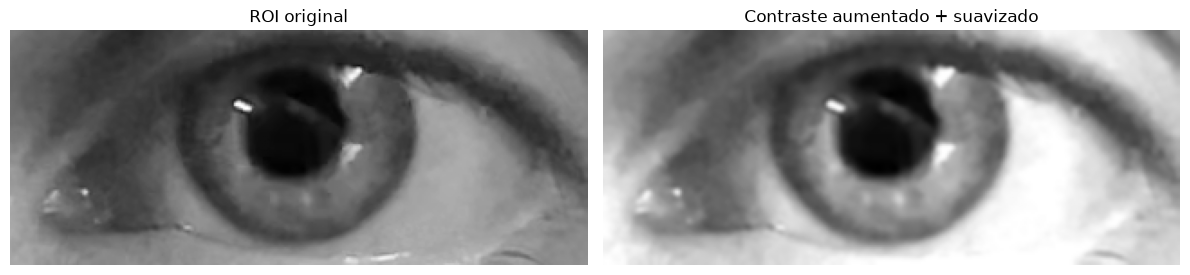

In [76]:
roi_contraste = np.clip(
    roi_gray.astype(np.float32) * 1.5,
    0,
    255
).astype(np.uint8)

roi_suavizada = cv2.GaussianBlur(
    roi_contraste,
    (5, 5),
    0
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(roi_gray, cmap="gray")
plt.title("ROI original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(roi_suavizada, cmap="gray")
plt.title("Contraste aumentado + suavizado")
plt.axis("off")

plt.tight_layout()
plt.show()

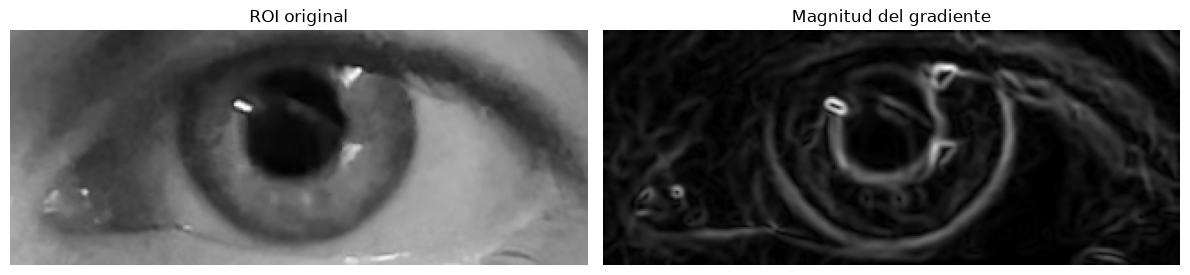

In [77]:
# Gradiente horizontal y vertical
grad_x = cv2.Sobel(
    roi_suavizada,
    cv2.CV_64F,
    1, 0,
    ksize=7
)

grad_y = cv2.Sobel(
    roi_suavizada,
    cv2.CV_64F,
    0, 1,
    ksize=7
)

# Magnitud del gradiente
gradiente = cv2.magnitude(
    grad_x.astype(np.float32),
    grad_y.astype(np.float32)
)

# Normalización para visualizar
gradiente_norm = cv2.normalize(
    gradiente,
    None,
    0, 255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(roi_gray, cmap="gray")
plt.title("ROI original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gradiente_norm, cmap="gray")
plt.title("Magnitud del gradiente")
plt.axis("off")

plt.tight_layout()
plt.show()

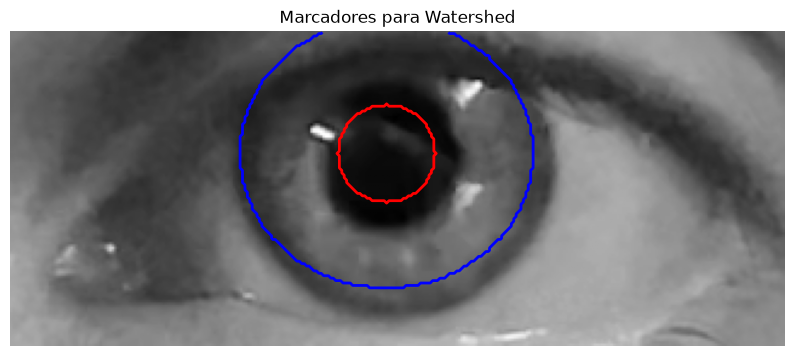

In [78]:
markers = np.zeros(roi_gray.shape, dtype=np.int32)

# Región pequeña dentro de la pupila
cv2.circle(
    markers,
    (int(center_x), int(center_y)),
    20,
    1,
    -1
)

# Todo lo que esté fuera de esta elipse
# se considera background seguro.
roi_mask = np.zeros(roi_gray.shape, dtype=np.uint8)

cv2.ellipse(
    roi_mask,
    (int(center_x), int(center_y)),
    (60, 55),
    0,
    0,
    360,
    1,
    -1
)

# Background seguro = fuera de la elipse
markers[roi_mask == 0] = 2

plt.figure(figsize=(10, 7))

plt.imshow(roi_gray, cmap="gray")

plt.contour(
    markers == 1,
    colors="r",
    linewidths=2
)

plt.contour(
    markers == 2,
    colors="b",
    linewidths=2
)

plt.title("Marcadores para Watershed")
plt.axis("off")
plt.show()

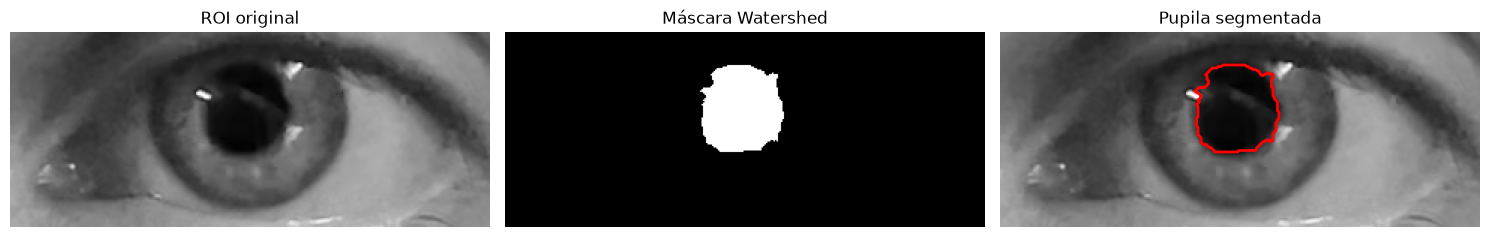

In [79]:
roi_bgr = cv2.cvtColor(roi_suavizada,cv2.COLOR_GRAY2BGR)

markers_ws = cv2.watershed(roi_bgr,markers.copy())

mask_watershed = (markers_ws == 1).astype(np.uint8) * 255

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(roi_gray, cmap="gray")
plt.title("ROI original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_watershed, cmap="gray")
plt.title("Máscara Watershed")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(roi_gray, cmap="gray")
plt.contour(
    mask_watershed > 0,
    colors="r",
    linewidths=2
)
plt.title("Pupila segmentada")
plt.axis("off")

plt.tight_layout()
plt.show()

Con el método de Watershed, se obtiene un contorno bastante cercano al de la pupila pero irregular. 

Ahora aplicamos erosión, dilatación, apertura y cierre sobre la máscara binaria obtenida por watershed, puesto que es la que mejor segmenta la pupila. Buscamos visualizar la eliminación de destellos luminosos (reflejos corneales del flash), oclusión por pestañas o sombras que pide la consigna si utilizamos dicha máscara para aplicar las operaciones.
La eliminación de dichos artefactos se observa mejor mediante la máscara de Otsu pero se busca continuar con una segmentación adecuada de la pupila. 
Las propiedades morfológicas se utilizan para remover imperfecciones de la imagen segmentada para luego obtener información de la estructura y forma de los objetos.

El kernel determina el tamaño del kernel del elemento estructurante que se utiliza en cada operación. Un kernel demasiado grande puede borrar partes de la pupila o alterar su forma, mientras que uno muy pequeño puede no producir cambios útiles. Es por esto que elegimos un kernel mediano (5x5)

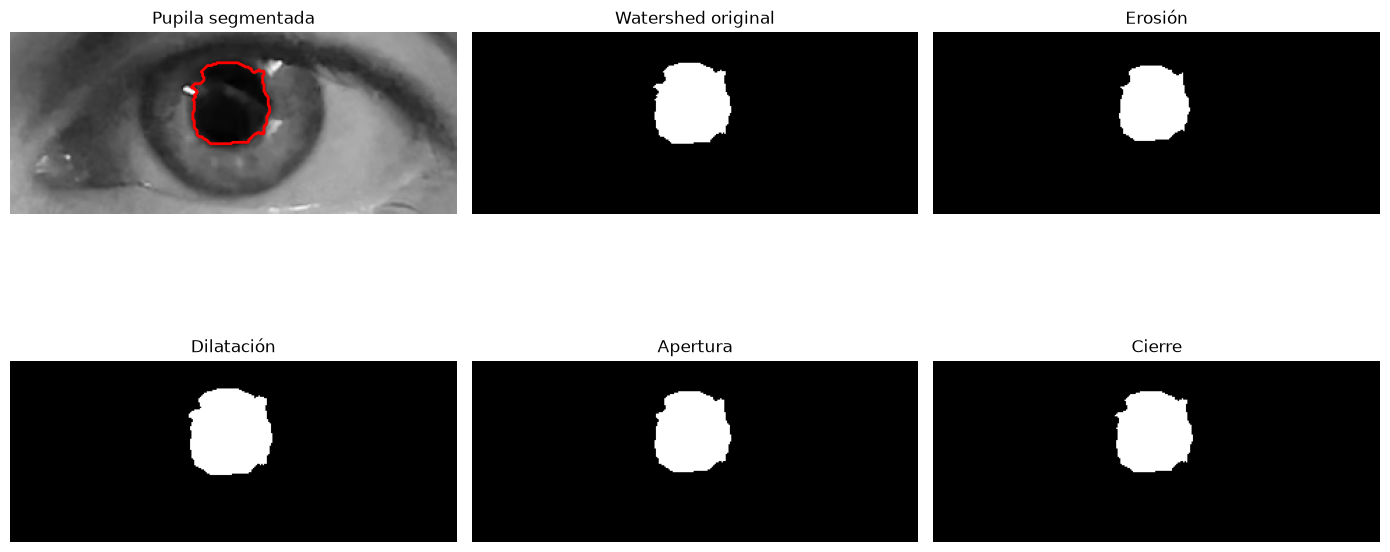

In [80]:
# Usamos directamente la máscara que ya tenemos de Otsu, sin operaciones morfológicas
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5, 5))

# Aplicar operaciones morfológicas
mask_erosion = cv2.erode(mask_watershed, kernel, iterations=1)
mask_dilatacion = cv2.dilate(mask_watershed, kernel, iterations=1)
mask_apertura = cv2.morphologyEx(mask_watershed, cv2.MORPH_OPEN, kernel)
mask_cierre = cv2.morphologyEx(mask_watershed, cv2.MORPH_CLOSE, kernel)

resultados = {
    "Watershed original": mask_watershed,
    "Erosión": mask_erosion,
    "Dilatación": mask_dilatacion,
    "Apertura": mask_apertura,
    "Cierre": mask_cierre}

plt.figure(figsize=(14, 8))
plt.subplot(2, 3, 1)
plt.imshow(roi_gray, cmap="gray")
plt.contour(
    mask_watershed > 0,
    colors="r",
    linewidths=2
)
plt.title("Pupila segmentada")
plt.axis("off")

for i, (nombre, mascara) in enumerate(resultados.items()):
    plt.subplot(2, 3, i + 2)
    plt.imshow(mascara, cmap="gray")
    plt.title(nombre)
    plt.axis("off")

plt.tight_layout()
plt.show()

Luego, genero la esqueletización, donde me quedo con la estructura mínima que conserva la forma del objeto original. Pretende obtener de la imagen un patrón continuo que contenga la menor cantidad de datos posibles, pero que siga aún, conteniendo un rastro del objeto original

Genero el esqueleto a partir del algoritmo de watershed. Este es mucho más preciso para la segmentación de la pupila.

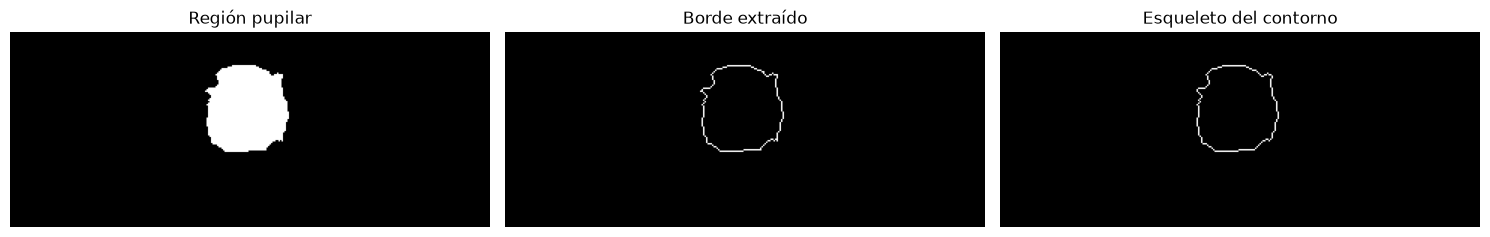

In [81]:
from skimage.morphology import skeletonize

# Extraemos los contornos externos de la región pupilar
contornos, _ = cv2.findContours(mask_watershed.copy(),cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

# Dibujamos el contorno sobre la ROI original
imagen_contorno = cv2.cvtColor(roi_gray,cv2.COLOR_GRAY2RGB)

# Creamos un borde fino a partir de la máscara de Watershed
kernel_borde = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3, 3))
borde_pupila = cv2.subtract(mask_watershed,cv2.erode(mask_watershed, kernel_borde))

# Esqueletizamos el borde extraído
esqueleto = skeletonize(borde_pupila > 0)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(mask_watershed, cmap="gray")
plt.title("Región pupilar")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(borde_pupila, cmap="gray")
plt.title("Borde extraído")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(esqueleto, cmap="gray")
plt.title("Esqueleto del contorno")
plt.axis("off")
plt.tight_layout()
plt.show()


Ahora genero combinaciones de las operaciones morfológicas

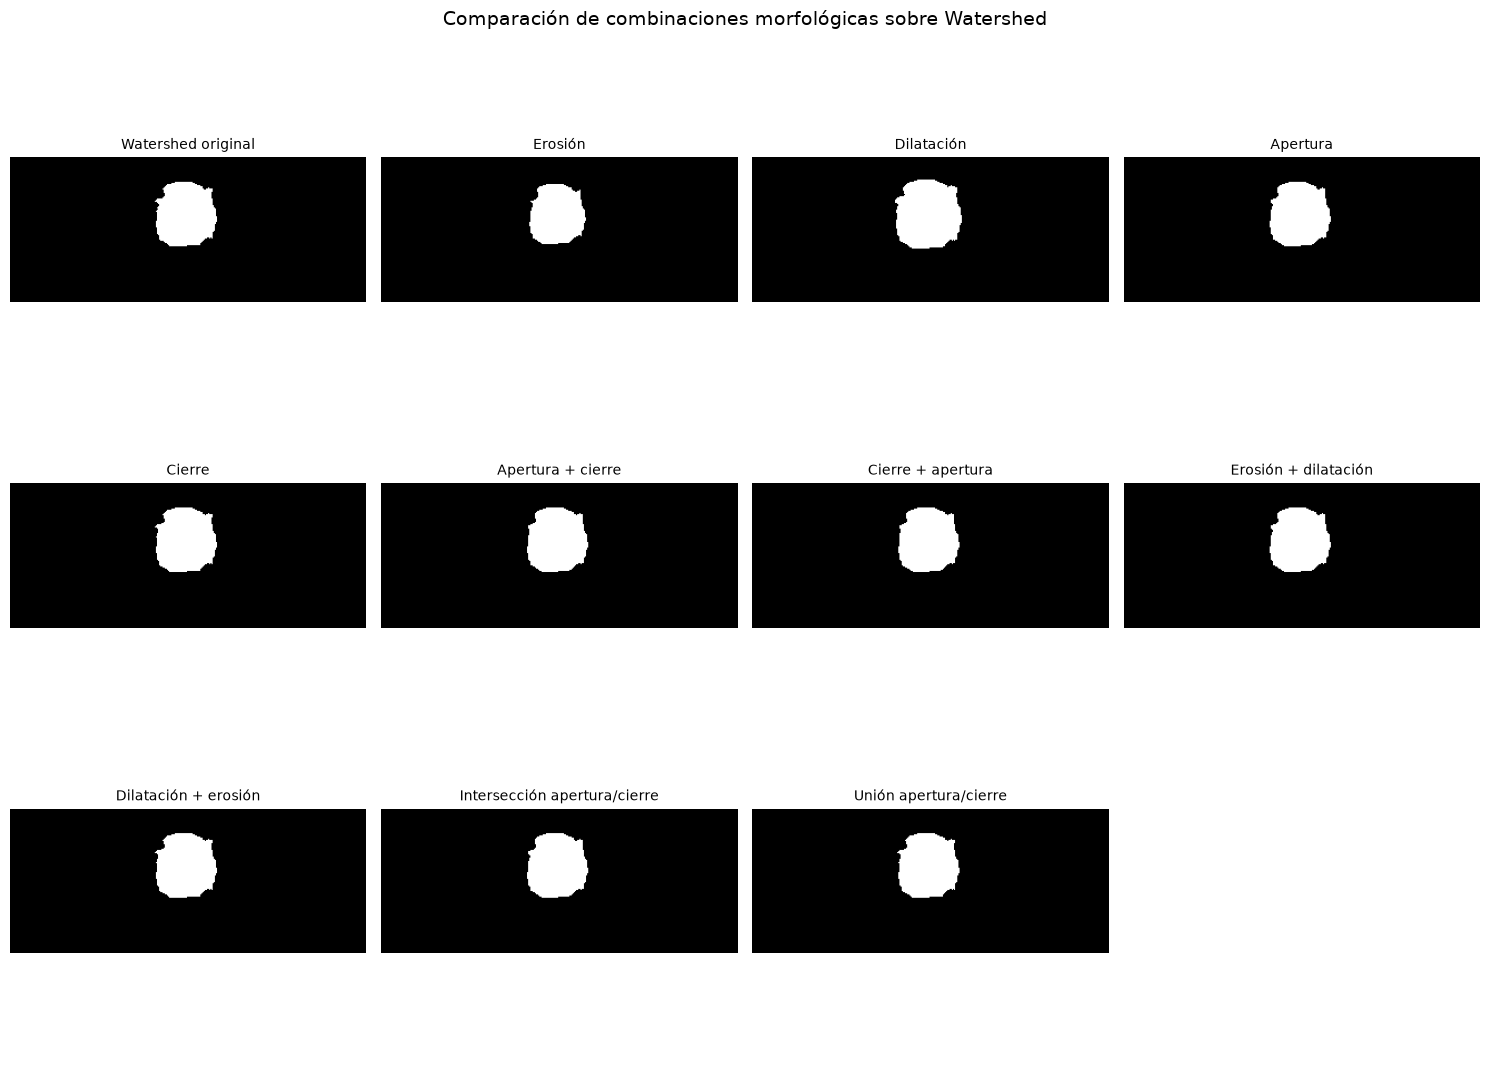

In [82]:
# Genero operaciones secuenciales
apertura_cierre = cv2.morphologyEx(cv2.morphologyEx(mask_watershed * 255, cv2.MORPH_OPEN, kernel),
                                   cv2.MORPH_CLOSE, kernel) > 0
cierre_apertura = cv2.morphologyEx(cv2.morphologyEx(mask_watershed * 255, cv2.MORPH_CLOSE, kernel),
                                   cv2.MORPH_OPEN, kernel) > 0
erosion_dilatacion = cv2.dilate(cv2.erode(mask_watershed * 255, kernel), kernel) > 0
dilatacion_erosion = cv2.erode(cv2.dilate(mask_watershed * 255, kernel), kernel) > 0

# Combino máscaras ya calculadas
interseccion_ap_cie = np.logical_and(mask_apertura > 0, mask_cierre > 0)
union_ap_cie = np.logical_or(mask_apertura > 0, mask_cierre > 0)

mascaras = {
    "Watershed original": mask_watershed,
    "Erosión": mask_erosion,
    "Dilatación": mask_dilatacion,
    "Apertura": mask_apertura,
    "Cierre": mask_cierre,
    "Apertura + cierre":apertura_cierre,
    "Cierre + apertura": cierre_apertura,
    "Erosión + dilatación": erosion_dilatacion,
    "Dilatación + erosión": dilatacion_erosion,
    "Intersección apertura/cierre": interseccion_ap_cie,
    "Unión apertura/cierre": union_ap_cie
}

fig, axes = plt.subplots(3, 4, figsize=(15, 11))
axes = axes.ravel()

for ax, (nombre, mascara) in zip(axes, mascaras.items()):
    ax.imshow(mascara, cmap="gray", vmin=0, vmax=1)
    ax.set_title(nombre, fontsize=10)
    ax.axis("off")

# Ocultar paneles sobrantes
for ax in axes[len(mascaras):]:
    ax.axis("off")

plt.suptitle(
    "Comparación de combinaciones morfológicas sobre Watershed",
    fontsize=14
)
plt.tight_layout()
plt.show()

Por último, comparamos la combinación de máscaras resultantes basandonos en la segmentación watershed, considerando el área segmentada, el cambio porcentual de área y las métricas Dice e IoU calculadas respecto de la máscara original. Estas últimas se utilizaron para cuantificar las modificaciones introducidas por cada operación, y no como una medida directa de precisión respecto de la pupila real.

In [83]:
import pandas as pd

def calcular_metricas(mascara, original):
    pred = np.asarray(mascara) > 0
    base = np.asarray(original) > 0

    interseccion = np.logical_and(pred, base).sum()
    union = np.logical_or(pred, base).sum()

    area = pred.sum()
    area_original = base.sum()

    # Solapamiento con la máscara original (no con la pupila real)
    iou_original = (interseccion / union if union > 0 else 1.0)

    dice_original = (2 * interseccion / (area + area_original)
        if (area + area_original) > 0 else 1.0 )

    cambio_area_pct = (100 * (area - area_original) / area_original
        if area_original > 0 else 0.0)

    pixeles_modificados_pct = (100 * np.logical_xor(pred, base).sum() / base.size)

    return {
        "Área (píxeles)": area,
        "Cambio de área (%)": cambio_area_pct,
        "Dice vs. Watershed": dice_original,
        "IoU vs. Watershed": iou_original,
        "Píxeles modificados (%)": pixeles_modificados_pct
    }
resultados = []

for nombre, mascara in mascaras.items():
    metricas = calcular_metricas(mascara, mask_watershed)
    metricas["Método"] = nombre
    resultados.append(metricas)

tabla = pd.DataFrame(resultados).set_index("Método")

display(tabla.round(4))

,Área (píxeles),Cambio de área (%),Dice vs. Watershed,IoU vs. Watershed,Píxeles modificados (%)
Método,,,,,
Watershed original,2632,0.0000,1.0000,1.0000,0.0000
Erosión,2230,-15.2736,0.9173,0.8473,0.9663
Dilatación,3062,16.3374,0.9245,0.8596,1.0337
Apertura,2615,-0.6459,0.9968,0.9935,0.0409
Cierre,2638,0.2280,0.9989,0.9977,0.0144
Apertura + cierre,2619,-0.4939,0.9960,0.9920,0.0505
Cierre + apertura,2623,-0.3419,0.9960,0.9920,0.0505
Erosión + dilatación,2615,-0.6459,0.9968,0.9935,0.0409
Dilatación + erosión,2638,0.2280,0.9989,0.9977,0.0144


La tabla muestra que la erosión fue la que más área de la pupila quitó mientras que la dilatación la que más agregó. Estos cambios evidencian que ambas operaciones modifican de manera más significativa el tamaño de la región, por lo que su aplicación debe evaluarse cuidadosamente para evitar la pérdida de partes de la pupila o la incorporación de regiones ajenas a ella.

La operación de apertura modificó una proporción muy pequeña de la segmentación mientras que el cierre, en cambio, no produjo cambios medibles en la máscara para el elemento estructurante utilizado.

Las combinaciones evaluadas tampoco generaron mejoras cuantitativas apreciables respecto de la máscara original, pero podríamos considerar que una de ellas es la más adecuada ya que mantiene significatimente la morfología de la pupila, reduciendo solo donde es necesario y cuya comparación con watershed (Dice o IoU) está más cercano al valor unitario. Siguiendo este criterio podríamos decir que el cierre, una combinación compuesta por dilatación seguida de erosión o la unión entre cierre y apertura son las combinaciones más óptimas.